# 02_分类算法-朴素贝叶斯

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这里聊一个非常核心算法模型：朴素贝叶斯。

先来简单介绍一下\~

朴素贝叶斯（Naive Bayes）是一种基于贝叶斯定理的简单概率分类器，它基于特征之间的独立性假设，因此称为"朴素"。尽管这个假设在现实世界中很少成立，但朴素贝叶斯仍然是许多文本分类和垃圾邮件过滤等问题中的一种常用方法，因为它易于实现、速度快，并且在许多情况下表现良好。

历史上，朴素贝叶斯方法最初由英国数学家托马斯·贝叶斯（Thomas Bayes）在18世纪提出，但他的著作是在他去世后于1763年出版的。他的论文题为《关于逆概率问题的一种方法》，主要探讨了如何根据已知的事件发生频率来推断原因。这篇论文中包含了贝叶斯定理的雏形，该定理是朴素贝叶斯分类器的基础。

朴素贝叶斯分类器的实际应用在20世纪50年代至60年代得到了推动，当时计算机科学家开始探索基于统计学习的方法解决模式识别问题。从那时起，朴素贝叶斯就成为了机器学习领域中的一个重要工具，在文本和模式识别等领域取得了广泛应用。

### 理论基础

朴素贝叶斯（Naive Bayes）分类器是基于贝叶斯定理和特征独立性假设的一种简单概率分类器。它假设特征之间相互独立，即给定类别，特征之间不存在关联关系。

尽管这个假设在现实中很少成立，但朴素贝叶斯在文本分类和垃圾邮件过滤等问题上表现良好。

### 数学原理

#### 贝叶斯定理

贝叶斯定理描述了在已知先验概率的情况下，如何根据新的观察结果来更新概率。对于类别变量 $C_k$ 和特征变量 $X_1, X_2, ..., X_n$，贝叶斯定理可以表示为：


$$
P(C_k|X_1, X_2, ..., X_n) = \frac{P(C_k) \times P(X_1, X_2, ..., X_n|C_k)}{P(X_1, X_2, ..., X_n)}
$$


其中，

- $P(C_k|X_1, X_2, ..., X_n)$ 是在给定观察结果 $X_1, X_2, ..., X_n$ 的条件下，类别变量为 $C_k$ 的后验概率；
- $P(C_k)$ 是类别变量 $C_k$ 的先验概率；
- $P(X_1, X_2, ..., X_n|C_k)$ 是在类别变量为 $C_k$ 的情况下观察结果 $X_1, X_2, ..., X_n$ 的条件概率；
- $P(X_1, X_2, ..., X_n)$ 是观察结果 $X_1, X_2, ..., X_n$ 的边缘概率。

#### 朴素贝叶斯分类器

朴素贝叶斯分类器假设特征之间相互独立，即给定类别，特征之间不存在关联关系。基于这个假设，可以将贝叶斯定理改写为：


$$
P(C_k|X_1, X_2, ..., X_n) = \frac{P(C_k) \times \prod_{i=1}^{n} P(X_i|C_k)}{P(X_1, X_2, ..., X_n)}
$$


为了进行分类，我们选择具有最大后验概率的类别作为预测结果，即：


$$
\hat{y} = \arg\max_{k} P(C_k) \times \prod_{i=1}^{n} P(X_i|C_k)
$$


### 算法流程

1. **准备数据**：将数据集划分为训练集和测试集。
2. **计算先验概率**：对于每个类别 $C_k$，计算 $P(C_k)$，即该类别在训练集中的频率。
3. **计算条件概率**：对于每个特征 $X_i$ 和每个类别 $C_k$，计算 $P(X_i|C_k)$，即在给定类别 $C_k$ 的情况下，特征 $X_i$ 的条件概率。可以根据特征的类型（离散或连续）采用不同的计算方法，如对于离散特征，可以计算其在每个类别下的频率；对于连续特征，可以假设其服从某种概率分布（如高斯分布）并估计参数。
4. **预测类别**：对于每个样本的特征向量 $(X_1, X_2, ..., X_n)$，根据贝叶斯定理计算每个类别的后验概率，并选择具有最大后验概率的类别作为预测结果。
5. **评估模型**：使用测试集评估模型的性能，通常使用准确率、精确率、召回率等指标进行评估。
6. **调优参数**：根据评估结果，可以调整模型的参数（如特征选择、平滑参数等）来提高模型性能。

朴素贝叶斯分类器的优点是简单易懂，速度快，对小规模数据表现良好。然而，由于特征独立性假设的限制，它在处理特征之间存在关联关系的数据时可能表现不佳。

### 一个案例

下面，使用朴素贝叶斯分类器对鸢尾花数据集进行分类，并使用可视化来展示分类结果。

代码中，还包含了一些算法优化，如特征缩放和参数调优。

最佳参数: {'var_smoothing': np.float64(0.01873817422860384)}
准确率：0.9777777777777777


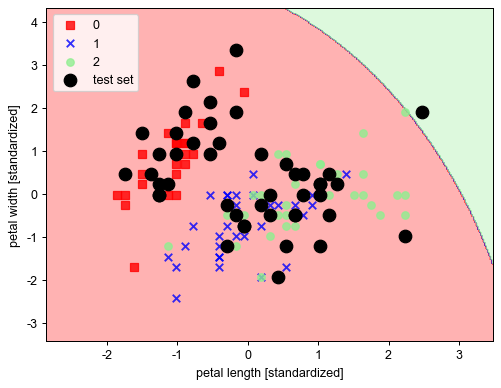

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
from sklearn.model_selection import GridSearchCV

# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 划分数据集为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 特征缩放
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 创建朴素贝叶斯分类器
classifier = GaussianNB()

# 定义要调优的参数范围
params = {'var_smoothing': np.logspace(0, -9, num=100)}

# 使用 GridSearchCV 进行参数调优
grid_search = GridSearchCV(estimator=classifier, param_grid=params, cv=10, error_score='raise')
grid_search.fit(X_train, y_train)

# 输出最佳参数
print(f"最佳参数: {grid_search.best_params_}")

# 使用最佳参数重新训练模型
best_classifier = grid_search.best_estimator_
best_classifier.fit(X_train, y_train)

# 预测测试集结果
y_pred = best_classifier.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f'准确率：{accuracy}')

# 创建可视化函数
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    
    # 修改这里，使用所有四个特征
    if X.shape[1] > 2:
        XX = np.array([xx1.ravel(), xx2.ravel()] + [np.zeros_like(xx1.ravel()) for _ in range(X.shape[1]-2)]).T
    else:
        XX = np.array([xx1.ravel(), xx2.ravel()]).T

    Z = classifier.predict(XX)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=[cmap(idx)],
                    marker=markers[idx], label=cl)

    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1], c='black', edgecolors='black', alpha=1.0, linewidths=1, marker='o', s=100, label='test set')

# 可视化分类结果
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X=X_combined, y=y_combined, classifier=best_classifier, test_idx=range(105, 150))
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_014.png)

在以上的代码中， 使用了高斯朴素贝叶斯分类器来对鸢尾花数据集进行分类，并包含了参数调优和可视化分类结果的部分。

下面我来大概得解释一下，便于大家理解\~

1. **数据加载与预处理**：

   - 使用 `datasets.load_iris()` 加载鸢尾花数据集，包括特征数据 `X` 和标签 `y`。
   - 使用 `train_test_split` 将数据集划分为训练集 `X_train, y_train` 和测试集 `X_test, y_test`，其中测试集占比为 30%。
2. **特征缩放**：

   - 使用 `StandardScaler` 对训练集和测试集的特征数据进行标准化处理，使其均值为 0，方差为 1。
3. **创建朴素贝叶斯分类器**：

   - 使用 `GaussianNB` 创建一个高斯朴素贝叶斯分类器对象 `classifier`。
4. **参数调优**：

   - 定义了一个参数范围 `params`，包含 `var_smoothing` 参数的一系列取值。
   - 使用 `GridSearchCV` 在训练集上进行交叉验证，寻找最佳的 `var_smoothing` 参数。这一步通过网格搜索的方式遍历参数空间，找到最优的参数值。
5. **模型训练与评估**：

   - 使用最佳参数的高斯朴素贝叶斯分类器 `best_classifier` 对训练集进行训练。
   - 使用训练好的模型对测试集进行预测，得到预测结果 `y_pred`。
   - 计算预测准确率 `accuracy_score`，评估模型性能。
6. **可视化分类结果**：

   - 定义了一个函数 `plot_decision_regions`，用于绘制决策边界和数据点。
   - 使用 `plot_decision_regions` 函数绘制训练集和测试集的分类结果，突出了不同类别的数据点和决策边界。

最后通过可视化展示了分类结果\~

### 应用场景

朴素贝叶斯适用于分类问题，特别是在特征维度高、样本量小的情况下表现良好。它在文本分类（如垃圾邮件过滤、情感分析）、推荐系统、医学诊断等领域有广泛应用。

**优点**：

- 简单快速：算法简单易懂，计算速度快。
- 高效性：在小规模数据上表现良好。
- 对缺失数据不敏感：对于缺失数据，朴素贝叶斯可以假设缺失数据对分类没有影响。

**缺点**：

- 特征独立假设限制了模型表达能力。
- 对输入数据的分布假设过于简单，可能导致模型在某些情况下表现不佳。

**前提条件**：

- 特征之间应该是相互独立的，尽管这在实际中很少成立。
- 数据集应该包含足够的样本以准确估计先验概率和条件概率。

**应用案例**：

在垃圾邮件过滤中，我们可以使用朴素贝叶斯来预测一封邮件是否为垃圾邮件。假设我们有一个包含大量已分类为垃圾邮件和非垃圾邮件的邮件数据集，以及每封邮件的文本内容作为特征。

我们可以使用朴素贝叶斯分类器来训练一个模型，该模型能够根据邮件的文本内容预测其是否为垃圾邮件。模型在训练完成后，可以用于过滤收件箱中的新邮件，将预测为垃圾邮件的邮件放入垃圾箱，从而提高用户体验。